In [112]:
import yfinance as yf
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD, PSARIndicator
from ta.volatility import BollingerBands
from ta.utils import dropna

In [113]:
df = pd.read_csv('EURUSD_Official_Fetures_Included.csv')
print(df.shape)
df.head()

(5730, 21)


,Date,Open,High,Low,Close,Adj Close,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff,...,volatility_bbl,volatility_bbh,trend_psar,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width,above_psar,Target
0,2003-12-01,1.203398,1.204007,1.194401,1.196501,1.196501,NaN,NaN,NaN,NaN,...,NaN,NaN,1.196501,NaN,NaN,NaN,NaN,NaN,0,1.208897
1,2003-12-02,1.196101,1.210903,1.194600,1.208897,1.208897,NaN,NaN,NaN,NaN,...,NaN,NaN,1.208897,NaN,NaN,1.196501,NaN,NaN,0,1.212298
2,2003-12-03,1.209000,1.213003,1.207700,1.212298,1.212298,NaN,NaN,NaN,NaN,...,NaN,NaN,1.204007,NaN,NaN,1.208897,NaN,NaN,1,1.208094
3,2003-12-04,1.212004,1.214403,1.204398,1.208094,1.208094,NaN,NaN,NaN,NaN,...,NaN,NaN,1.207700,NaN,NaN,1.212298,NaN,NaN,1,1.218695
4,2003-12-05,1.207802,1.219096,1.206593,1.218695,1.218695,NaN,NaN,NaN,NaN,...,NaN,NaN,1.214403,NaN,NaN,1.208094,NaN,NaN,1,1.222001


In [114]:
df = df.dropna()

In [115]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff,...,volatility_bbl,volatility_bbh,trend_psar,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width,above_psar,Target
5724,2025-12-23,1.176443,1.180359,1.176429,1.176595,1.176595,66.505649,0.004011,0.003264,0.000747,...,1.154761,1.179718,1.169817,79.358165,63.521956,1.170809,0.874867,0.010690,1,1.179551
5725,2025-12-24,1.179565,1.180916,1.177426,1.179551,1.179551,69.581354,0.004386,0.003488,0.000897,...,1.155841,1.180946,1.171084,92.898212,73.598855,1.176595,0.944467,0.010743,1,1.178536
5726,2025-12-26,1.178384,1.179941,1.176304,1.178536,1.178536,67.296544,0.004548,0.003700,0.000848,...,1.156605,1.182014,1.172460,87.617459,86.624612,1.179551,0.863147,0.010865,1,1.177274
5727,2025-12-29,1.177496,1.178856,1.175406,1.177274,1.177274,64.460963,0.004523,0.003865,0.000658,...,1.157776,1.182572,1.173644,81.048460,87.188043,1.178536,0.786342,0.010595,1,1.177288
5728,2025-12-30,1.177302,1.178134,1.174619,1.177288,1.177288,64.478770,0.004453,0.003983,0.000471,...,1.159165,1.182896,1.180916,80.575126,83.080348,1.177274,0.763668,0.010132,0,1.174729


In [116]:
df = df.set_index('Date')

In [117]:
df.head()

,Open,High,Low,Close,Adj Close,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff,volatility_bbm,volatility_bbl,volatility_bbh,trend_psar,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width,above_psar,Target
Date,,,,,,,,,,,,,,,,,,,,
2004-01-15,1.265599,1.267106,1.256897,1.260097,1.260097,55.164333,0.012355,0.013950,-0.001595,1.258827,1.230817,1.286837,1.288725,39.699406,55.316378,1.265102,0.522663,0.022251,0,1.239803
2004-01-16,1.260001,1.261002,1.236400,1.239803,1.239803,43.224293,0.009374,0.013035,-0.003661,1.258892,1.231067,1.286718,1.287762,6.383659,31.992083,1.260097,0.156975,0.022103,0,1.235407
2004-01-19,1.238697,1.242406,1.234004,1.235407,1.235407,41.146781,0.006581,0.011744,-0.005163,1.258668,1.230169,1.287167,1.285708,2.518041,16.200369,1.239803,0.091895,0.022642,0,1.258907
2004-01-20,1.235102,1.260208,1.234995,1.258907,1.258907,53.902449,0.006193,0.010634,-0.004441,1.259613,1.232429,1.286797,1.282606,44.706250,17.869317,1.235407,0.487008,0.021581,0,1.265903
2004-01-21,1.258099,1.266994,1.256597,1.265903,1.265903,56.897553,0.006376,0.009782,-0.003406,1.260643,1.234155,1.287132,1.279689,57.266066,34.830119,1.258907,0.599282,0.021012,0,1.272508


In [118]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'momentum_rsi',
       'trend_macd', 'trend_macd_signal', 'trend_macd_diff', 'volatility_bbm',
       'volatility_bbl', 'volatility_bbh', 'trend_psar', 'momentum_stoch',
       'momentum_stoch_signal', 'Close_Lag1', 'bb_percent_b', 'bb_width',
       'above_psar', 'Target'],
      dtype='object')

In [122]:
X = df[['momentum_rsi','trend_macd_diff','momentum_stoch','momentum_stoch_signal','Close_Lag1','bb_percent_b','bb_width']]

In [123]:
X.head()

,momentum_rsi,trend_macd_diff,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width
Date,,,,,,,
2004-01-15,55.164333,-0.001595,39.699406,55.316378,1.265102,0.522663,0.022251
2004-01-16,43.224293,-0.003661,6.383659,31.992083,1.260097,0.156975,0.022103
2004-01-19,41.146781,-0.005163,2.518041,16.200369,1.239803,0.091895,0.022642
2004-01-20,53.902449,-0.004441,44.706250,17.869317,1.235407,0.487008,0.021581
2004-01-21,56.897553,-0.003406,57.266066,34.830119,1.258907,0.599282,0.021012


In [124]:
y = df['Target']

In [125]:
y.head()

Date
2004-01-15    1.239803
2004-01-16    1.235407
2004-01-19    1.258907
2004-01-20    1.265903
2004-01-21    1.272508
Name: Target, dtype: float64

# Train Test Split

In [126]:
split_date = '2022-01-01'

In [127]:
train_mask = df.index<split_date if df.index.name=='Date' else df['Date']<split_date
test_mask =~train_mask

In [128]:
X_train,X_test = X[train_mask],X[test_mask]

In [129]:
X_train

,momentum_rsi,trend_macd_diff,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width
Date,,,,,,,
2004-01-15,55.164333,-0.001595,39.699406,55.316378,1.265102,0.522663,0.022251
2004-01-16,43.224293,-0.003661,6.383659,31.992083,1.260097,0.156975,0.022103
2004-01-19,41.146781,-0.005163,2.518041,16.200369,1.239803,0.091895,0.022642
2004-01-20,53.902449,-0.004441,44.706250,17.869317,1.235407,0.487008,0.021581
2004-01-21,56.897553,-0.003406,57.266066,34.830119,1.258907,0.599282,0.021012
...,...,...,...,...,...,...,...
2021-12-27,49.357627,0.001354,68.820675,71.710461,1.132734,0.720904,0.004570
2021-12-28,50.099073,0.001373,73.392045,71.595406,1.132426,0.752662,0.004685
2021-12-29,48.095309,0.001244,58.369052,66.860591,1.133003,0.618561,0.004583


In [130]:
X_test

,momentum_rsi,trend_macd_diff,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width
Date,,,,,,,
2022-01-03,55.088326,0.001404,95.984331,83.462628,1.132503,0.996288,0.005751
2022-01-04,46.676381,0.000992,45.766188,67.860916,1.137346,0.442210,0.005688
2022-01-05,44.752262,0.000578,32.636455,58.128991,1.130224,0.292578,0.005629
2022-01-06,48.425488,0.000492,53.700855,44.034499,1.128363,0.541128,0.005446
2022-01-07,46.570740,0.000318,29.912664,38.749991,1.131350,0.404532,0.005432
...,...,...,...,...,...,...,...
2025-12-23,66.505649,0.000747,79.358165,63.521956,1.170809,0.874867,0.010690
2025-12-24,69.581354,0.000897,92.898212,73.598855,1.176595,0.944467,0.010743
2025-12-26,67.296544,0.000848,87.617459,86.624612,1.179551,0.863147,0.010865


In [131]:
y_train,y_test = y[train_mask],y[test_mask]

In [132]:
y_test.tail()

Date
2025-12-23    1.179551
2025-12-24    1.178536
2025-12-26    1.177274
2025-12-29    1.177288
2025-12-30    1.174729
Name: Target, dtype: float64

In [133]:
print(f"Train Size:{len(X_train)}, Test Size:{len(X_test)}")

Train Size:4658, Test Size:1038


In [69]:
from sklearn.metrics import  mean_absolute_error, mean_squared_error

In [70]:
baseline_pred = df.loc[X_test.index, 'Close']

In [74]:
baseline_mae = mean_absolute_error(y_test,baseline_pred)
baseline_rsme = np.sqrt(mean_squared_error(y_test,baseline_pred))
baseline_mape = np.mean(np.abs(y_test - baseline_pred)/y_test)*100

In [76]:
print(f"base line MAE:{baseline_mae:.5f}")
print(f"base line RSME:{baseline_rsme:.5f}")
print(f"base line MAPE:{baseline_mape:.2f}%")

base line MAE:0.00400
base line RSME:0.00534
base line MAPE:0.37%


# Decision Tree

In [79]:
from sklearn.tree import DecisionTreeRegressor

In [81]:
dt_model = DecisionTreeRegressor(max_depth = 5, random_state = 42)
dt_model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [85]:
dt_pred = dt_model.predict(X_test)

In [86]:
dt_mae = mean_absolute_error(y_test,dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test,dt_pred))
dt_mape = np.mean(np.abs(y_test - dt_pred)/y_test)*100

In [87]:
print(f"Decision Tree MAE: {dt_mae:.5f}")
print(f"Decision Tree RMSE: {dt_rmse:.5f}")
print(f"Decision Tree MAPE: {dt_mape:.2f}%")

Decision Tree MAE: 0.01196
Decision Tree RMSE: 0.02067
Decision Tree MAPE: 1.15%


In [88]:
dt_train_pred = dt_model.predict(X_train)

In [89]:
dt_train_mae = mean_absolute_error(y_train,dt_train_pred)
dt_train_rmse = np.sqrt(mean_squared_error(y_train,dt_train_pred))
dt_train_mape = np.mean(np.abs(y_train - dt_train_pred)/y_train)*100

In [90]:
print(f"Decison Tree Train MAE:{dt_train_mae:.5f}")
print(f"Decision Tree Train RMSE:{dt_train_rmse:.5f}")
print(f"Decision Tree Train MAPE:{dt_train_mape:.2f}%")

Decison Tree Train MAE:0.00848
Decision Tree Train RMSE:0.01231
Decision Tree Train MAPE:0.67%


# Random Forest 

In [92]:
from sklearn.ensemble import RandomForestRegressor

In [96]:
rf_model = RandomForestRegressor(n_estimators = 200, max_depth = 5, random_state = 42, n_jobs = -1)

In [97]:
rf_model.fit(X_train,y_train)

RandomForestRegressor(max_depth=5, n_estimators=200, n_jobs=-1, random_state=42)

In [98]:
rf_pred = rf_model.predict(X_test)
rf_train_pred  = rf_model.predict(X_train)

In [99]:
rf_mae = mean_absolute_error(y_test,rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test,rf_pred))
rf_mape = np.mean(np.abs(y_test - rf_pred)/y_test)*100

In [100]:
rf_train_mae = mean_absolute_error(y_train,rf_train_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_train,rf_train_pred))
rf_train_mape = np.mean(np.abs(y_train - rf_train_pred)/y_train)*100

In [101]:
print(f"Random Forest Train MAE:{rf_train_mae:.5f}    Test MAE:{rf_mae:.5f}")
print(f"Random Forest Train RMSE:{rf_train_rmse:.5f}    Test RMSE:{rf_rmse:.5f}")
print(f"Random Forest Train MAPE:{rf_train_mape:.2f}%    Test MAPE:{rf_mape:.2f}%")

Random Forest Train MAE:0.00772    Test MAE:0.01086
Random Forest Train RMSE:0.01139    Test RMSE:0.01941
Random Forest Train MAPE:0.61%    Test MAPE:1.04%


<AxesSubplot:title={'center':'Random Forest Feature Importance'}>

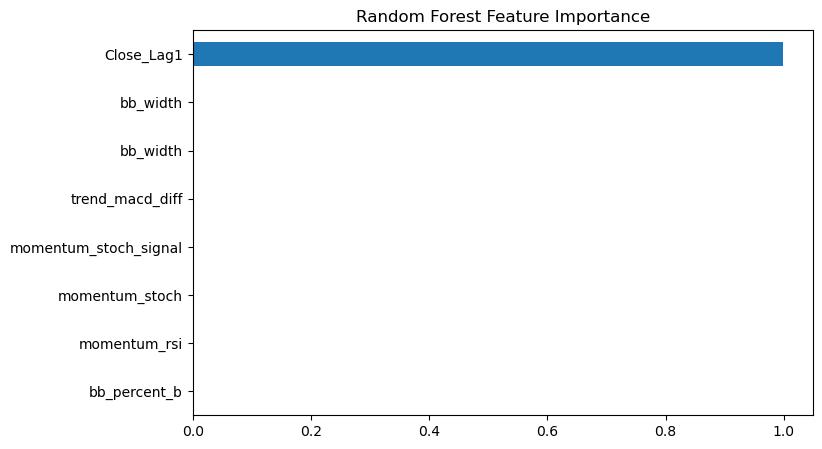

In [102]:
importance = pd.Series(rf_model.feature_importances_,index=X_train.columns)
importance.sort_values(ascending=True).plot(kind='barh',figsize=(8,5), title="Random Forest Feature Importance")

# XGBoost

In [105]:
from xgboost import XGBRegressor

In [134]:
xgb_model = XGBRegressor(
    n_estimators = 200,
    max_depth = 5,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    n_jobs = -1
    
)

xgb_model.fit(X_train,y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_train_pred = xgb_model.predict(X_train)

In [135]:
xgb_mae = mean_absolute_error(y_test,xgb_pred)
xgb_rsme = np.sqrt(mean_squared_error(y_test,xgb_pred))
xgb_mape = np.mean(np.abs(y_test - xgb_pred)/y_test)*100

In [136]:
xgb_train_mae = mean_absolute_error(y_train,xgb_train_pred)
xgb_train_rsme = np.sqrt(mean_squared_error(y_train,xgb_train_pred))
xgb_train_mape = np.mean(np.abs(y_train - xgb_train_pred)/y_train)*100

In [137]:
print(f"XGB trian MAE:{xgb_train_mae:.5f}    XGB test MAE:{xgb_mae:.5f}")
print(f"XGB train RSME:{xgb_train_rsme:.5f}  XGB test RSME:{xgb_rsme:.5f}")
print(f"XGB train MAPE:{xgb_train_mape:.2f}%  XGB test MAPE:{xgb_mape:.2f}%")

XGB trian MAE:0.00544    XGB test MAE:0.01051
XGB train RSME:0.00748  XGB test RSME:0.01837
XGB train MAPE:0.43%  XGB test MAPE:1.01%


Close_Lag1               0.946737
momentum_stoch_signal    0.014277
momentum_rsi             0.012499
trend_macd_diff          0.010804
bb_width                 0.008154
momentum_stoch           0.004959
bb_percent_b             0.002570
dtype: float32


<AxesSubplot:title={'center':'XGBoost Feature Importance (Close excluded)'}>

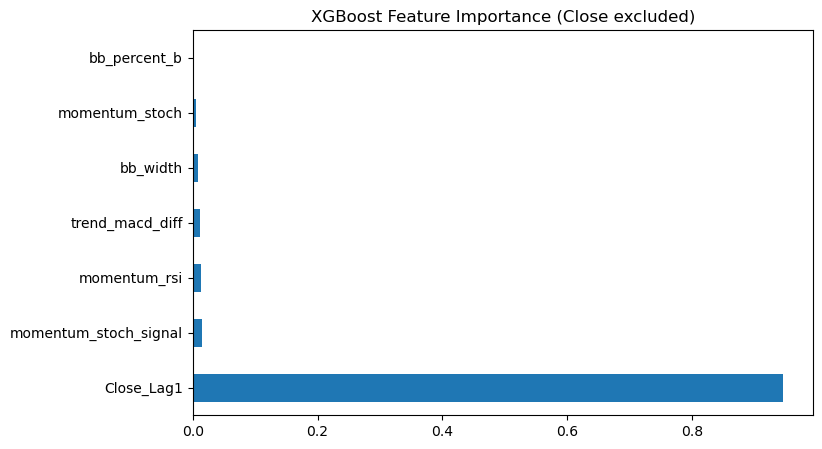

In [139]:
import pandas as pd

importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,5), title="XGBoost Feature Importance (Close excluded)")